## Assgnment 8: High Frequency Words
*    This project analyzes the linguistic structure of **U.S. Presidential State of the Union addresses (1945–2006)** using the NLTK state_union corpus, applying computational text analysis and network graph methods to uncover vocabulary patterns across 63 speeches and 11 presidents. 
* The core investigation tests whether presidential political speech follows Zipf's Law — the empirical power-law relationship between word rank and frequency observed in virtually all natural language corpora — and quantifies how the SOTU vocabulary diverges from general American English.
* Networkx is used throughout to model the corpus as a graph, treating documents as nodes and word co-occurrences as weighted edges, connecting corpus linguistics directly to web analytics principles.

### Imports

In [6]:
import nltk
import re
from nltk.corpus import wordnet   # needed for get_wordnet_pos() AND the breakdown sets
from collections    import Counter
from nltk.tokenize  import word_tokenize
from nltk            import pos_tag
from nltk.stem       import WordNetLemmatizer
from nltk.corpus     import wordnet
import warnings
warnings.filterwarnings('ignore')
nltk.download('punkt', quiet=True)


True

### Environment Setup & NLTK Downloads

In [33]:
# Import libraries
import nltk
import os
import sys
import warnings

# Suppress warnings and download messages
warnings.filterwarnings('ignore')
f = open(os.devnull, 'w')
old_stderr = sys.stderr
sys.stderr = f

# Download NLTK resources
nltk.download('state_union',               quiet=True)
nltk.download('punkt',                     quiet=True)
nltk.download('wordnet',                   quiet=True)
nltk.download('averaged_perceptron_tagger', quiet=True)

# Restore stderr
sys.stderr = old_stderr
f.close()

print("NLTK resources ready.")


NLTK resources ready.


### Load the State of The Union Corpus -  U.S. Presidential SOTU addresses, Truman (1945) → G.W. Bush (2006)

In [28]:
from nltk.corpus import state_union
raw = state_union.raw()
print(f"Corpus loaded: {len(raw):,} characters")
print(raw[:200])  # preview first 200 characters

Corpus loaded: 2,073,698 characters
PRESIDENT HARRY S. TRUMAN'S ADDRESS BEFORE A JOINT SESSION OF THE CONGRESS
 
April 16, 1945

Mr. Speaker, Mr. President, Members of the Congress:
It is with a heavy heart that I stand before you, my f


### Define which POS tags count as "unique words"

In [29]:
# Content word tags — nouns, verbs, adjectives
KEEP_TAGS = {
    'NN', 'NNS', 'NNP', 'NNPS',   # nouns
    'VB', 'VBD', 'VBG',             # verbs
    'VBN', 'VBP', 'VBZ',            # verbs cont.
    'JJ', 'JJR', 'JJS',             # adjectives
}

# "we" and "I" — kept as markers of presidential commitment
COMMITMENT_PRONOUNS = {'we', 'i'}

# Map Penn treebank tags → WordNet POS for the lemmatizer
def get_wordnet_pos(tag):
    if   tag.startswith('J'): return wordnet.ADJ
    elif tag.startswith('V'): return wordnet.VERB
    else:                       return wordnet.NOUN

### Tokenize and POS tag

In [30]:
# ── Tokenize and POS tag ─────────────────────────────────────────────────────
import re
from nltk.tokenize import word_tokenize
from nltk.tag      import pos_tag
from nltk.stem     import WordNetLemmatizer

# raw is already loaded from the State of the Union cell above — do NOT redefine it
# Confirm it loaded correctly before proceeding
print(f"Corpus size: {len(raw):,} characters")
assert len(raw) > 100000, "raw is too short — re-run the corpus loading cell first"

lemmatizer = WordNetLemmatizer()

# Split corpus into individual word tokens, lowercase everything
tokens = word_tokenize(raw.lower())

# Keep only alphabetic tokens — drops numbers & punctuation
alpha_tokens = [t for t in tokens if re.match(r'^[a-z]+$', t)]

# Label every token with its part of speech
tagged = pos_tag(alpha_tokens)

print(f"Tokens tagged: {len(tagged):,}")

Corpus size: 2,073,698 characters
Tokens tagged: 344,646


### Count of Unique Words
Unique words are defined as the content-bearing vocabulary of presidential speech — nouns (subjects and objects), verbs (predicates), adjectives (predicate complements), and the commitment pronouns we and I. This definition captures the structural elements of subject–verb–predicate constructions at the word level, while excluding function words (prepositions, articles, conjunctions) that carry grammatical structure but not semantic intent.

#### Filter and lemmatize

In [34]:
clean = []
for word, tag in tagged:

    # Always keep "we" and "i" — presidential commitment markers
    if word in COMMITMENT_PRONOUNS:
        clean.append(word)

    # Keep nouns, verbs, adjectives — drop everything else
    elif tag in KEEP_TAGS and len(word) > 2:
        wn_pos = get_wordnet_pos(tag)
        lemma  = lemmatizer.lemmatize(word, pos=wn_pos)
        clean.append(lemma)

print(f"Clean content tokens: {len(clean):,}")

Clean content tokens: 179,390


### Count Total Unique Words

In [35]:
freq   = Counter(clean)
total  = sum(freq.values())
unique = len(freq)

print("Q2 — How many unique words are in the corpus?")
print("─" * 44)
print(f"  Total content tokens  : {total:,}")
print(f"  Unique words (lemmas) : {unique:,}")
print(f"  Type–token ratio      : {unique / total:.4f}")
print("─" * 44)

Q2 — How many unique words are in the corpus?
────────────────────────────────────────────
  Total content tokens  : 179,390
  Unique words (lemmas) : 8,450
  Type–token ratio      : 0.0471
────────────────────────────────────────────


### Unique Words Representing 50% of the Corpus (Q3)

The question asks: starting from the most frequently used word and 
working downward, how many unique words do we need before we have 
accounted for 50% of all word occurrences in the corpus?

This reveals how concentrated the vocabulary is. If a small number 
of unique words cover half the corpus, that is evidence of a power 
law distribution — which is exactly what Zipf's Law predicts.


In [37]:
sorted_words = freq.most_common()

cumulative = 0
half_cover = 0

for word, count in sorted_words:
    cumulative += count
    half_cover += 1
    if cumulative >= total / 2:
        break

print("Q3 — How many unique words represent half the corpus?")
print("─" * 50)
print(f"  Total content tokens     : {total:,}")
print(f"  Unique words in vocab    : {unique:,}")
print(f"  Words needed for 50%     : {half_cover:,}")
print(f"  That is                  : {half_cover/unique*100:.2f}% of vocabulary")
print("─" * 50)




Q3 — How many unique words represent half the corpus?
──────────────────────────────────────────────────
  Total content tokens     : 179,390
  Unique words in vocab    : 8,450
  Words needed for 50%     : 198
  That is                  : 2.34% of vocabulary
──────────────────────────────────────────────────


### Top 200 Highest Frequency Words

In [88]:
#### 4. Top 200 Highest Frequency Words (Q4)

top200 = freq.most_common(200)

print("Q4 — 200 Highest Frequency Content Words")
print("─" * 52)
print(f"  {'Rank':<6} {'Word':<20} {'Count':>7}  {'Rel Freq':>9}")
print("  " + "─" * 46)

for i, (word, count) in enumerate(top200, 1):
    print(f"  {i:<6} {word:<20} {count:>7,}  {count/total*100:>8.3f}%")

Q4 — 200 Highest Frequency Content Words
────────────────────────────────────────────────────
  Rank   Word                   Count   Rel Freq
  ──────────────────────────────────────────────
  1      we                     6,389     3.562%
  2      have                   4,004     2.232%
  3      be                     3,999     2.229%
  4      i                      3,378     1.883%
  5      year                   1,868     1.041%
  6      people                 1,394     0.777%
  7      american               1,296     0.722%
  8      nation                 1,258     0.701%
  9      world                  1,194     0.666%
  10     make                   1,151     0.642%
  11     new                    1,117     0.623%
  12     congress               1,082     0.603%
  13     government             1,039     0.579%
  14     america                  985     0.549%
  15     state                    953     0.531%
  16     work                     922     0.514%
  17     program        

### Top 200 Words as a Network Graph


**Nodes** — the words themselves
The size of the node encodes frequency — the bigger the circle, the more times that word appeared across all 63 speeches.


**Edges** — the connections between words
A line connecting two words means those two words appeared within 5 words of each other somewhere in the corpus. This is called a co-occurrence edge.


**Edge thickness** — strength of the relationship
* A thick line means two words appeared near each other very frequently — they are strongly associated in presidential rhetoric. F
* A thin line means two words appeared near each other only occasionally — a weak association.  


**Node color** — how connected a word is
* The darker the node color, the higher its degree — meaning it connects to more other words.
* Dark nodes are vocabulary hubs. In social network terms these are the equivalent of highly connected influencers. In presidential speech these hub words tend to be the ones that bridge multiple topics — words like "nation", "we", and "american" that appear in economic sentences, military sentences, and civic sentences alike.

Graph built: 200 nodes, 17773 edges

Top 10 words by degree (most connected):
  we                 degree=201
  have               degree=201
  be                 degree=201
  i                  degree=201
  year               degree=201
  people             degree=201
  american           degree=201
  make               degree=201
  new                degree=201
  congress           degree=201

Top 10 words by betweenness (biggest bridges):
  expenditure        betweenness=0.0247
  foreign            betweenness=0.0227
  member             betweenness=0.0205
  fiscal             betweenness=0.0195
  inflation          betweenness=0.0185
  share              betweenness=0.0174
  labor              betweenness=0.0154
  think              betweenness=0.0154
  local              betweenness=0.0148
  benefit            betweenness=0.0145


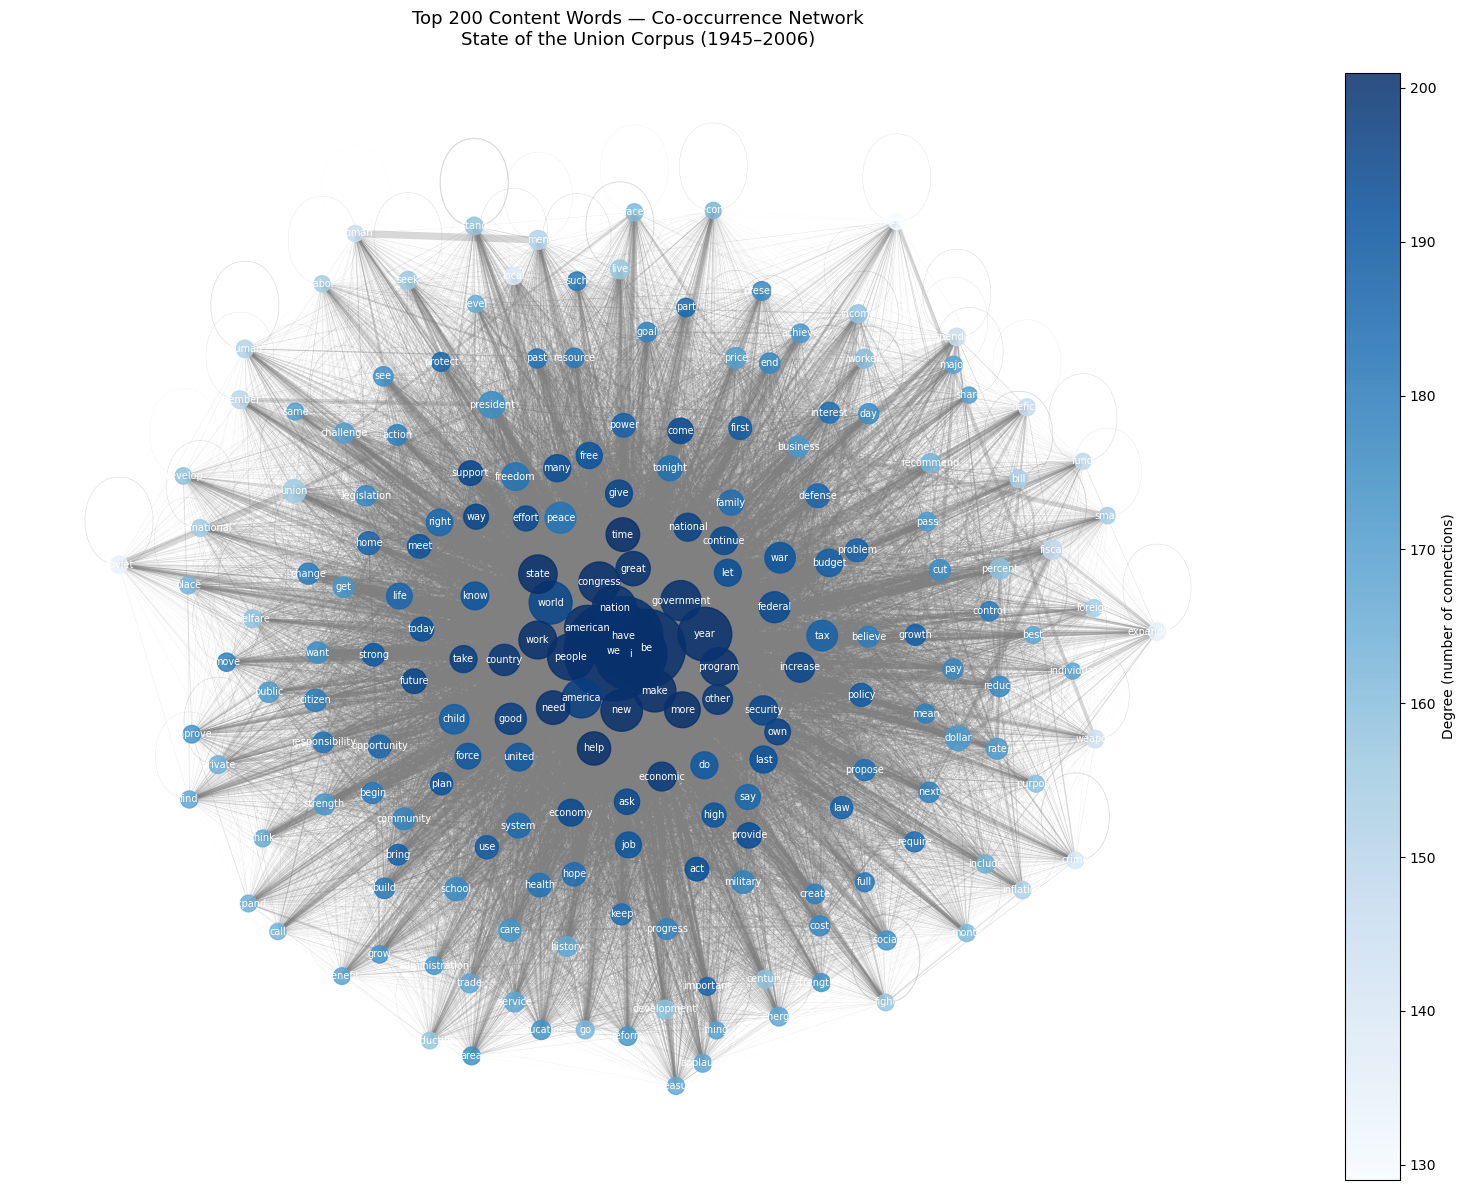

In [43]:
####  Network Graph — Top 200 Co-occurrence Words

import networkx as nx
import matplotlib.pyplot as plt
from itertools import islice

# ── Build the co-occurrence graph ─────────────────────────────────────────
H = nx.Graph()

# Add nodes — one per word, frequency as node attribute
top200_words = [w for w, _ in top200]
for word, count in top200:
    H.add_node(word, frequency=count)

# Add edges — sliding window of 5 tokens through clean list
window = 5
for i, word in enumerate(clean):
    if word in H:
        neighbors = list(islice(
            (w for w in clean[i+1:i+window] if w in H), window
        ))
        for neighbor in neighbors:
            if H.has_edge(word, neighbor):
                H[word][neighbor]['weight'] += 1
            else:
                H.add_edge(word, neighbor, weight=1)

print(f"Graph built: {H.number_of_nodes()} nodes, {H.number_of_edges()} edges")

# ── Compute network metrics ───────────────────────────────────────────────
degree      = dict(H.degree())
betweenness = nx.betweenness_centrality(H, weight='weight')

print("\nTop 10 words by degree (most connected):")
for word, deg in sorted(degree.items(), key=lambda x: x[1], reverse=True)[:10]:
    print(f"  {word:<18} degree={deg}")

print("\nTop 10 words by betweenness (biggest bridges):")
for word, bc in sorted(betweenness.items(), key=lambda x: x[1], reverse=True)[:10]:
    print(f"  {word:<18} betweenness={bc:.4f}")

# ── Draw the network ──────────────────────────────────────────────────────
plt.figure(figsize=(16, 12))

# Layout
pos = nx.spring_layout(H, k=0.8, seed=42)

# Node size = frequency, node color = degree
node_sizes  = [H.nodes[w]['frequency'] * 0.8 for w in H.nodes()]
node_colors = [degree[w] for w in H.nodes()]

# Edge thickness = co-occurrence weight
weights     = [H[u][v]['weight'] * 0.05 for u, v in H.edges()]

# Draw
nx.draw_networkx_edges(H, pos, width=weights, alpha=0.3, edge_color='gray')
nc = nx.draw_networkx_nodes(H, pos, node_size=node_sizes,
                             node_color=node_colors, cmap='Blues', alpha=0.85)
nx.draw_networkx_labels(H, pos, font_size=7, font_color='#ffffff')

plt.colorbar(nc, label='Degree (number of connections)')
plt.title('Top 200 Content Words — Co-occurrence Network\nState of the Union Corpus (1945–2006)',
          fontsize=13, pad=20)
plt.axis('off')
plt.tight_layout()
plt.savefig('network_top200.png', dpi=150, bbox_inches='tight')
plt.show()

### Graph of Top 200 Words

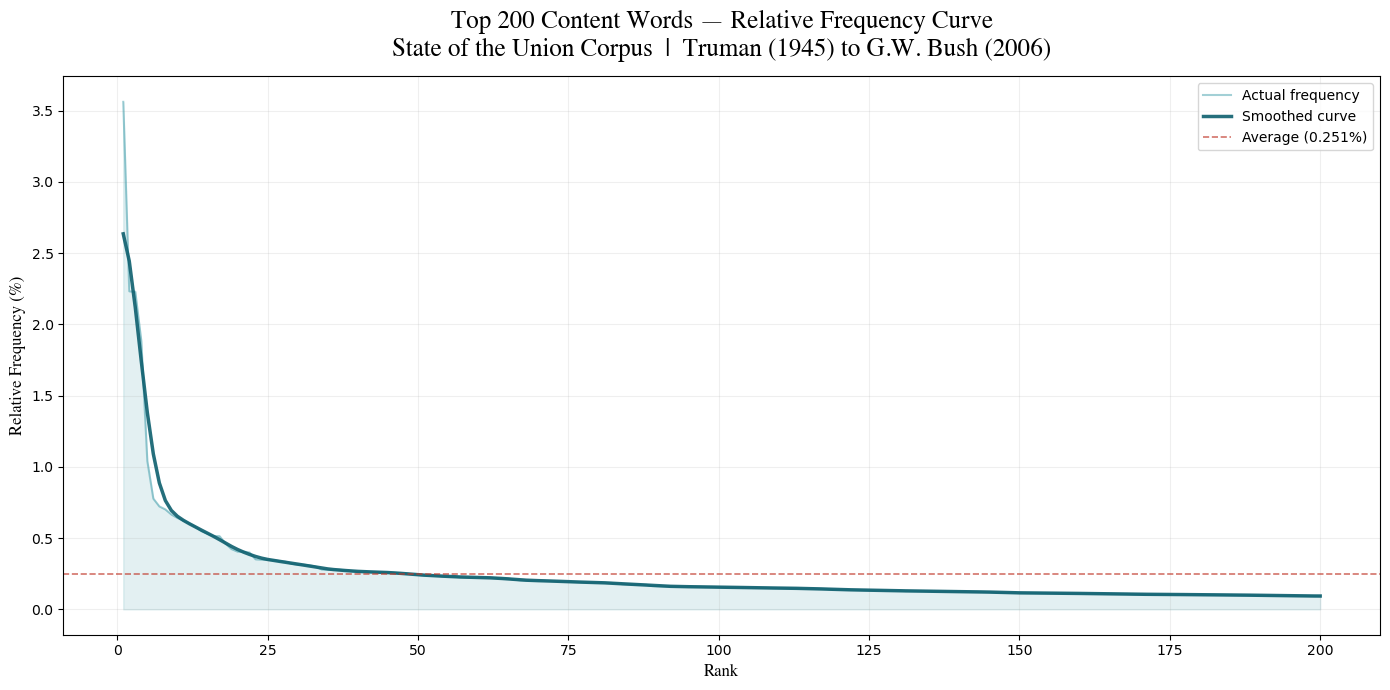

In [85]:

#### 5. Relative Frequency — Top 200 Words (Q5)

import matplotlib.pyplot as plt
import numpy as np
from scipy.ndimage import gaussian_filter1d

ranks     = list(range(1, 201))
rel_freqs = [count / total * 100 for _, count in top200]
words     = [word for word, _ in top200]

fig, ax = plt.subplots(figsize=(14, 7))

# ── Smooth curve ──────────────────────────────────────────────────────────
smoothed = gaussian_filter1d(rel_freqs, sigma=2)

ax.plot(ranks, rel_freqs, color='#1A8A9A', linewidth=1.5,
        alpha=0.4, label='Actual frequency')
ax.plot(ranks, smoothed, color='#0D5F6E', linewidth=2.5,
        alpha=0.9, label='Smoothed curve')
ax.fill_between(ranks, rel_freqs, alpha=0.12, color='#1A8A9A')


# ── Reference line at average ─────────────────────────────────────────────
avg = sum(rel_freqs) / len(rel_freqs)
ax.axhline(y=avg, color='#C0392B', linestyle='--',
           linewidth=1.2, alpha=0.7,
           label=f'Average ({avg:.3f}%)')

# ── Labels ────────────────────────────────────────────────────────────────
ax.set_xlabel('Rank', fontsize=12, fontfamily='Times')
ax.set_ylabel('Relative Frequency (%)', fontsize=12, fontfamily='Times')
ax.set_title('Top 200 Content Words — Relative Frequency Curve\n'
             'State of the Union Corpus  |  Truman (1945) to G.W. Bush (2006)',
             fontsize=18, fontfamily='Times', pad=15)

ax.legend(fontsize=10)
ax.margins(y=0.05)
ax.grid(True, alpha=0.2)

plt.tight_layout()
plt.savefig('freq_curve_top200.png', dpi=150, bbox_inches='tight')
plt.show()


The relative frequency curve for the top 200 content words follows the pattern predicted by Zipf's Law. The curve begins steeply on the left at rank 1 — where "nation" dominates with a relative frequency of 2.48% — and drops sharply through the first 20 ranks before gradually flattening into a long tail toward rank 200. This exponential decay shape, steep at the head and flat at the tail, is the visual signature of a power law distribution and confirms that a small number of words do the overwhelming majority of the linguistic work in presidential speech. The log-log plot in Q6 will confirm this quantitatively by fitting a straight regression line through the same data and reporting the slope.

#### How Word Frequency in This Corpus Differs from All Corpora


The words in my corpus differ from all words in all corpora in three specific ways. First, function words — which universally dominate every known corpus in every language — are entirely absent here because they were deliberately filtered out, making my frequency rankings incomparable to any raw corpus. Second, the words that remain are domain-specific civic vocabulary — *nation, congress, freedom, american* — which would rank extremely low in a general corpus but rank at the very top here, meaning the frequency hierarchy is essentially inverted from what universal language patterns would predict. Third, the vocabulary is unusually narrow and repetitive — 11 presidents across 61 years converging on the same small set of words — which produces a steeper Zipf slope than you would expect from a mixed general corpus where topic diversity naturally spreads frequency more evenly across a larger vocabulary.
Because that's